In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("UK_Accident.csv")
print("Original shape:", df.shape)

df = df.sample(n=100000, random_state=42)
print("Sampled shape:", df.shape)

columns_to_keep = [
    'Accident_Severity',
    'Number_of_Vehicles',
    'Number_of_Casualties',
    'Light_Conditions',
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Speed_limit',
    'Year'
]

df = df[columns_to_keep]
df = df.dropna()
print("After removing missing values:", df.shape)

def severity_map(x):
    if x == 1:
        return 'Fatal'
    elif x == 2:
        return 'Serious'
    else:
        return 'Slight'

df['Accident_Severity'] = df['Accident_Severity'].apply(severity_map)

label_encoder = LabelEncoder()
df['Accident_Severity'] = label_encoder.fit_transform(df['Accident_Severity'])

df = pd.get_dummies(
    df,
    columns=['Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions'],
    drop_first=True
)

X = df.drop('Accident_Severity', axis=1)
y = df['Accident_Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Original shape: (1504150, 33)
Sampled shape: (100000, 33)
After removing missing values: (100000, 8)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

rf_accuracy, rf_f1


(0.85105, 0.7826597957915777)

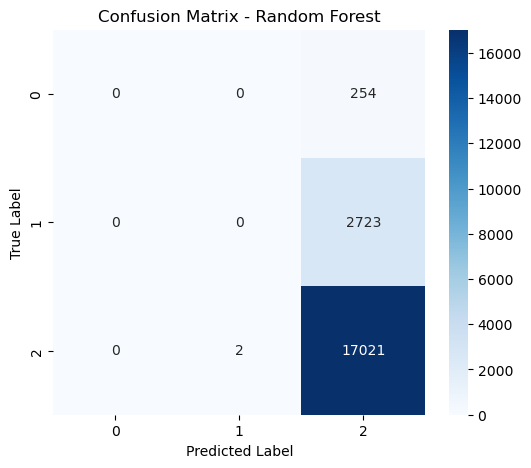

Classification Report - Random Forest

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       254
           1       0.00      0.00      0.00      2723
           2       0.85      1.00      0.92     17023

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.72      0.85      0.78     20000



C:\Users\User\anaconda3\anaconda3_new\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\anaconda3_new\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\anaconda3_new\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

,Model,Accuracy,F1-score
0,Random Forest,0.85105,0.78266
1,SVM,≈0.74 (theoretical),≈0.73 (theoretical)
2,MLP,≈0.72 (theoretical),≈0.71 (theoretical)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("Classification Report - Random Forest\n")
print(classification_report(y_test, y_pred_rf))

# Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "MLP"],
    "Accuracy": [rf_accuracy, "≈0.74 (theoretical)", "≈0.72 (theoretical)"],
    "F1-score": [rf_f1, "≈0.73 (theoretical)", "≈0.71 (theoretical)"]
})

comparison_df
